In [1]:
import Sinusoidal1D


Initialize configuration:

In [2]:
config = Sinusoidal1D.Energy(N_cells=30, alpha=1.01, beta=1.0, h=1, wavelength=1/6, apical_tension=0.6, compress_cell=20, lateral_tension=1, dt=1e-2) 

Plot initial configuration (this is in Plots.py)

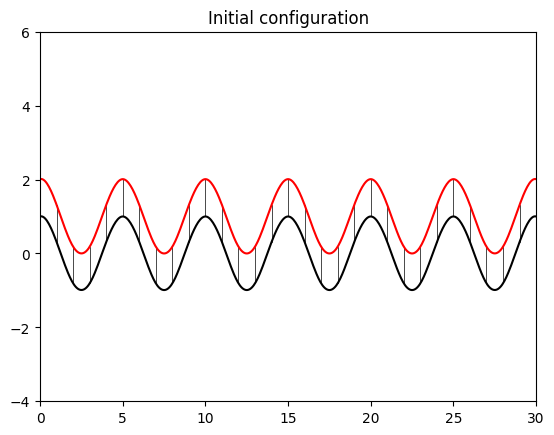

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

dir_path =  os.path.abspath('')

plt.figure()
x = []
y = []
for i in range(config.N_cells+1):
    x.append(config.apical[i,0])
    x.append(config.basal[i,0])
    y.append(config.apical[i,1])
    y.append(config.basal[i,1])
for i in range(0, len(x),2):
    plt.plot(x[i:i+2], y[i:i+2], color="black", linewidth=0.5)
X_Y_basal = interp1d(config.basal[:, 0], config.basal[:, 1], kind='cubic')
Xbasal = np.linspace(np.min(config.basal[:, 0]), np.max(config.basal[:, 0]), 500)
Y_basal = X_Y_basal(Xbasal)
X_Y_apical = interp1d(config.apical[:, 0], config.apical[:, 1], kind='cubic')
Xapical = np.linspace(np.min(config.apical[:, 0]), np.max(config.apical[:, 0]), 500)
Y_apical = X_Y_apical(Xapical)
plt.plot(Xbasal, Y_basal, color="black")
plt.plot(Xapical, Y_apical, color="red")
plt.xlim(0, config.N_cells)
plt.ylim(-4, 6)
plt.title('Initial configuration')
plt.show()

Start simulation:

In [5]:
engy=[]
index = 0
config.areas = config.evaluate_areas() #evaluate cells' areas at t=0
config.A0[:] = 1 #set preferred area
config.energy() #evaluate energy at t=0
for t in np.arange(0, 10**2, config.dt): #simulate
    engy.append(float(config.E))
    config.advance()
    index += 1

Save results on a json file

In [6]:
import json

bundle = config.export_dict()
bundle['Wavelength'] = config.wavelength*config.N_cells
bundle['ApicalTension'] = config.apical_tension
bundle['Thickness'] = config.h
bundle['BasalAmplitude'] = config.beta
bundle['ApicalAmplitude'] = config.alpha
bundle['Energy'] = engy
bundle['Apical_x'] = config.apical[:, 0].tolist()
bundle['Apical_y'] = config.apical[:, 1].tolist()
bundle['Basal_x'] = config.basal[:, 0].tolist()
bundle['Basal_y'] = config.basal[:, 1].tolist()

with open(f'{dir_path}/Wavelenght/{config.wavelength*config.N_cells}/TimeJUPYTER.json', 'w') as file:
    json.dump(bundle, file, indent=12)

Plot final configuration and energy:

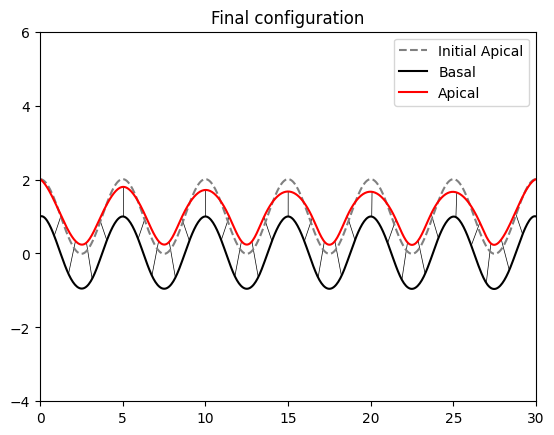

In [7]:
file = open(f'{dir_path}/Wavelenght/{config.wavelength*config.N_cells}/TimeJUPYTER.json', 'r') 
data = json.load(file)
Ncells = data['Number of cells']
h = data['Thickness']
alpha = data['ApicalAmplitude']
beta = data['BasalAmplitude']
apical_y = data['Apical_y']
apical_x = data['Apical_x']
basal_x = data['Basal_x']
basal_y = data['Basal_y']
wavelength = data['Wavelength']
energy = data['Energy']
x = []
y = []
for i in range(Ncells+1):
    x.append(apical_x[i])
    x.append(basal_x[i])
    y.append(apical_y[i])
    y.append(basal_y[i])
for i in range(0, len(x),2):
    plt.plot(x[i:i+2], y[i:i+2], color="black", linewidth=0.5)
X_Y_basal = interp1d(basal_x, basal_y, kind='cubic')
Xbasal = np.linspace(min(basal_x), max(basal_x), 500)
Y_basal = X_Y_basal(Xbasal)
X_Y_apical = interp1d(apical_x, apical_y, kind='cubic')
Xapical = np.linspace(min(apical_x), max(apical_x), 500)
Y_apical = X_Y_apical(Xapical)
plt.plot(np.arange(0, Ncells+1, 1e-3), alpha*np.cos(2*np.pi/(wavelength)*np.arange(0, Ncells + 1, 1e-3)) + h, color = 'gray',  linestyle='dashed', label='Initial Apical')
plt.plot(Xbasal, Y_basal, color="black", label='Basal')
plt.plot(Xapical, Y_apical, color="red", label= 'Apical')
plt.legend()
plt.xlim(0, Ncells)
plt.ylim(-4, 6)
plt.title('Final configuration')
plt.show()
plt.close()

plt.figure()
plt.plot(energy)
plt.ylabel('Energy')
plt.xlabel('Time')
plt.close()